<a href="https://colab.research.google.com/github/LzJusCodes/LzJusCodes.github.io/blob/main/Palm_Recognition_CSY2082.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# we start by mounting the dataset.

In [ ]:
!ls /content/drive/MyDrive/palm_dataset


palm_1b  palm_2c  palm_3e  palm_4e


In [ ]:
# ======
# We now import the tensorflow library for loading image datasets.
# ======
import tensorflow as tf
import numpy as np


In [ ]:
# =====
# We now define the dataset location
Directory_Data = "/content/drive/MyDrive/palm_dataset"

In [ ]:
# ==================
# Define image and training parameters.
#===================
img_sizing = (128, 128)
batch_sizes = 40
seed = 42

In [ ]:
# It is now time to generate the training dataset.
# We will use the parameter image dataset from directory, this will:
# - open images and assign them with labels
# resize them accordingly
# convert them to grayscale so that it doesn't get confused.
# splits the dataset
dataSet_trainer = tf.keras.utils.image_dataset_from_directory(
    Directory_Data,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    batch_size=batch_sizes,
    image_size=img_sizing, # Resize to IMG_Size
    shuffle=True, # This will make sure we reduce the bias as much as possible.
    seed=seed # ensuring we have a good split that remains somewhat constant.
)

value_ds = tf.keras.utils.image_dataset_from_directory(
    Directory_Data,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=img_sizing,
    batch_size=batch_sizes,
    shuffle=True,
    seed=seed
)

Found 168 files belonging to 4 classes.
Found 168 files belonging to 4 classes.


In [ ]:
# This next line will allow us to investigate the class labels and
# print out the relational data between folder names and numeric labels.
class_name = dataSet_trainer.class_names
print(class_name)

['palm_1b', 'palm_2c', 'palm_3e', 'palm_4e']


In [ ]:
# Rescaling the images for stability purposes, it's just easier to process from 0-1 than 0 to 255.
normalisation =  tf.keras.layers.Rescaling(1./255)

In [ ]:
dataSet_trainer = dataSet_trainer.map(lambda x, y: (normalisation(x), y), num_parallel_calls=tf.data.AUTOTUNE)
value_ds = value_ds.map(lambda x, y: (normalisation(x), y))

Since the dataset is particularly small, I will utilise data augmentation.
For training purposes only I have opted not to apply it within my piipeline. The reasoning for this is that it can actually affect my validation and give me false positives if I am not careful.

In [ ]:
augmented_data = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1),
], name="augmented_data")

Optimising the input pipeline

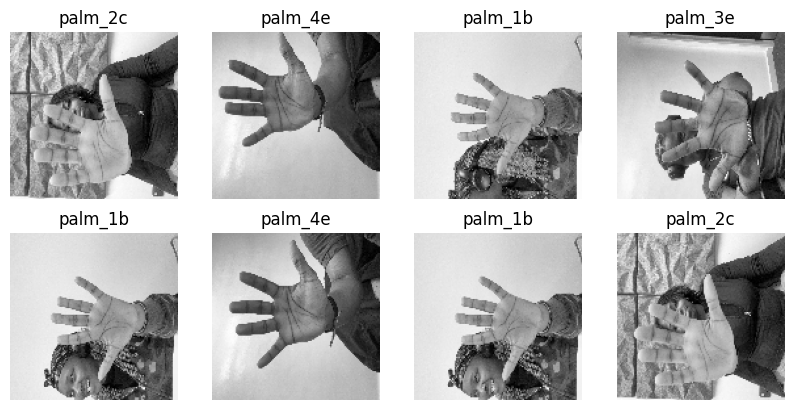

In [ ]:
import matplotlib.pyplot as plt

for images, labels in dataSet_trainer.take(1):
  plt.figure(figsize=(10, 10))
  for i in range(min(8, images.shape[0])):
    ax = plt.subplot(4, 4, i + 1)

    img = images[i].numpy()
    img = np.squeeze(img)

    plt.imshow(img, cmap="gray")
    plt.title(class_name[int(labels[i])])
    plt.axis("off")
plt.show()

We will now proceed to build the fundamentals in order to help the neural network beginning it's training phase. Beginning with the project config.

In [ ]:
cfg = {
    "img_h": 128,
    "img_w": 128,
    "img_c": 1,
    "lr": 8e-4
    "epochs": 40
    "dropout":0.35,
    "seed": 42
}

# We will now assume the number of classes from the folders that TensorFlow finds
k_classes = len(class_names)
print("Number of Detected classes is: ", class_names)
print("The overall number of classes is: ", k_classes)

In [ ]:
# I am going to attempt to use a mini block function to make my structure a bit more distinct to how others would do it.
# By using conv I can find the local texture; which would be the creasing details in the palm.
# BatchNorm and ReLU will add non-linearity.
def conv_bn_relu(x, filters, k=3, name_prefix="black")
  x = tf.keras.layers.Conv2D(
      filters, (k, k), padding="same", use_bias=False,
      kernel_initializer="he_normal",
      name=f"{name_prefix}_conv"
  )(x)
  x = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(x)
  x = tf.keras.layers.Activation("relu", name=f"{name_prefix}_relu")(x)
  return x

Now that is complete, we will now assemble the palm classifier which will be in a functional Application Programming Interface.

This is much more modular in the long run as it makes it easier to expand the code scope later on with extra stuff.

In [ ]:
input = tf.keras.Input(shape=(cfg["img_h"], cfg["img_w"], cfg["img_c"]), name="palm_input")

# Now I will flow the augmentation within the model itself so it only runs during the training phase.
x = data_augmentation(input)

# Time to assemble the palm feature extratonator.
x = conv_bn_relu(x, 16, name_prefix="stage1_a")
x = tf.keras.layers.MaxPooling2D(name="stage1_pool")(x)